In [23]:
import time, logging, importlib
import helpers; importlib.reload(helpers)

# 1. Cache check: second serial_ports() call should be ~instant
t0 = time.perf_counter(); helpers.serial_ports(); t1 = time.perf_counter()
helpers.serial_ports(); t2 = time.perf_counter()
print(f"serial_ports first: {t1-t0:.3f}s, cached: {t2-t1:.5f}s")

# 2. INFO-level discovery: should print exactly one "[helpers] Found device at: ..."
helpers.findDevice(question="hello\n", answer="NEW", flush=True, timeout=4)

# 3. Bump to DEBUG and re-run: now you should see "[helpers] Received message: ..." per port
logging.getLogger("helpers").setLevel(logging.DEBUG)
helpers.findDevice(question="hello\n", answer="NEW", flush=True, timeout=4)

# 4. Reset to INFO
logging.getLogger("helpers").setLevel(logging.INFO)


serial_ports first: 0.060s, cached: 0.00010s
[helpers] No matching device found
[helpers] Received message: MiniPAR,V1.1, port: COM13
[helpers] Received message: MiniPAR,V1.1, port: COM24
[helpers] Received message: , port: COM25
[helpers] Received message: NEW Name Here Ready, port: COM38
[helpers] Found device at: COM38, answer: NEW Name Here Ready



In [24]:
import sys
import time
import serial
import glob
from matplotlib import pyplot as plt
import numpy as np
from helpers import (
    findDevice, set_voltage, set_current, get_par_MP, get_par_AMB,
    r_squared, plot_data_and_fit, set_par_gain, set_ambit_led_gain,
    set_ambit_led, ambit_reboot, AmbitInfo
)


In [25]:
# Initialize ports for Ambit
PORT_AMBIT = findDevice(question="hello\n", answer="NEW", flush=True, timeout=4)
if(PORT_AMBIT is None):
    PORT_AMBIT = findDevice(question="hello\n", answer="NEW", flush=True, timeout=4)



[helpers] Found device at: COM38, answer: NEW Name Here Ready



In [26]:

info = ambit_reboot(PORT_AMBIT)

print(info)

metadata = {
    "name": info.name,
    "firmware_version": info.FW,
    "isValid": info.IsValid,
    "old_actinic_gain": info.act_led_coeff,
    "old_light_slope": info.light_slope,
}

# print(metadata)


FW: b'0.0.4' (MAC=38514fa89110, size=539216B, date=Jul)
Name: b'AmbitV004', valid: True
Calibration: Spec(light_slope)=0.3169, Actinic(act_led_coeff)=250.0, Emit=1.0, Sun=1.0, Temp_offset=0.0, Temp_slope=1.0
Actinic curve: {50: 983, 100: 2032, 150: 3121, 200: 4174, 250: 5233}
ADPD cal: [0, 0, 0, 0, 0, 0] (chip v2)
MLX cal: [5829844, 78530480, 0, 6400, 4908155, 5829844, 67377408, -53767196, -39611924, 16384, 0, 10752, 10752, 69140899]
Metadata: {'lon': 0.0, 'lat': 0.0, 'alt': 0.0, 'time': 0, 'acc': 0.0, 'vacc': 0.0, 'info1': '8C', 'x': 0.0, 'y': 0.0, 'z': 0.0}


In [27]:
# Initialize ports for MiniPAR
#PORT_MINIPAR = findDevice(question="hello\n",answer="MiniPAR",flush=True,timeout=2)
PORT_MINIPAR_PAR = findDevice(question="get_name\n",answer="Par_REF",flush=True,timeout=2)
PORT_MINIPAR_EMIT = findDevice(question="get_name\n",answer="Emit_LED",flush=True,timeout=2)


[helpers] Found device at: COM13, answer: Par_REF

[helpers] Found device at: COM24, answer: Emit_LED



In [28]:
# Initialize ports for DC supply
PORT_DC_SOURCE = findDevice(question="*IDN?\n", answer="KIPRIM", flush=True, timeout=2)

[helpers] Found device at: COM25, answer: KIPRIM,DC310S,25011669,FV:V5.2.0



In [29]:
# Initialize ports for Ambit
PORT_AMBIT = findDevice(question="hello\n", answer="NEW", flush=True, timeout=4)
if(PORT_AMBIT is None):
    PORT_AMBIT = findDevice(question="hello\n", answer="NEW", flush=True, timeout=4)



[helpers] Found device at: COM38, answer: NEW Name Here Ready



In [30]:
# Check if devices are detected
if PORT_MINIPAR_PAR is None:
    print("MiniPAR PAR device not found.")
    exit(1)
if PORT_MINIPAR_EMIT is None:
    print("MiniPAR Emit LED device not found.")
    exit(1)
if PORT_AMBIT is None:
    print("Ambit device not found.") 
    exit(1)
if PORT_DC_SOURCE is None:
    print("DC Source device not found.")
    exit(1)

print("All devices detected")

print(get_par_MP(PORT_MINIPAR_PAR, raw=True))
print(get_par_MP(PORT_MINIPAR_EMIT, raw=True))
print(get_par_AMB(PORT_AMBIT, raw = True))

All devices detected
0.01
0.01
3.59


Old ambit PAR coefficient: 250.0


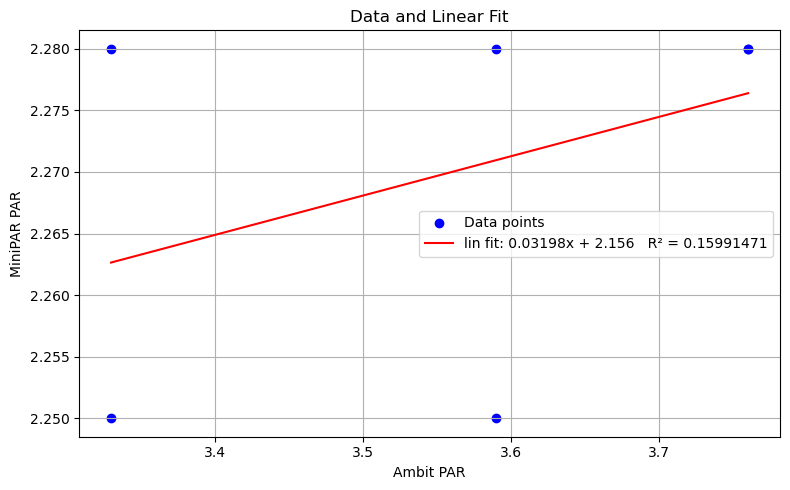

In [31]:
# callibration of the light sensor in the Ambit

currents = [0.2, 0.4, 0.8, 1.0, 1.6, 0]
reference_data = []
sensor_data = []
for I in currents:
    set_current(port=PORT_DC_SOURCE, current=I)
    time.sleep(1.0)
    ref_val = get_par_MP(PORT_MINIPAR_PAR)
    sens_val = get_par_AMB(PORT_AMBIT, raw=True)
    reference_data.append(ref_val)
    sensor_data.append(sens_val)

# Analysis functions
# (r_squared and plot_data_and_fit are now imported from helpers.py)

y = reference_data
x = sensor_data
coeffs = np.polyfit(x, y, 1)
y_pred = np.polyval(coeffs, x)
r2 = r_squared(y, y_pred)


# info about the fit
info = ambit_reboot(PORT_AMBIT)
print("Old ambit PAR coefficient:", info.act_led_coeff)
plot_data_and_fit(x, y, coeffs, r2, xlabel="Ambit PAR", ylabel="MiniPAR PAR")
 

In [32]:
# Upload PAR calibration coefficients to the Ambit
# This section demonstrates how to use set_par_gain
from helpers import set_par_gain, ambit_reboot, AmbitInfo

# Example:
slope = coeffs[0]
#offset = coeffs[1]
info = ambit_reboot(PORT_AMBIT)
old_slope =info.light_slope
print(f"Uploading PAR gain: {slope:.4f}")
set_par_gain(PORT_AMBIT, slope)
info = ambit_reboot(PORT_AMBIT)

print(f"Old PAR gain: {old_slope:.4f}, New PAR gain: {info.light_slope:.4f}") 

Uploading PAR gain: 0.0320
Old PAR gain: 0.3169, New PAR gain: 0.0320


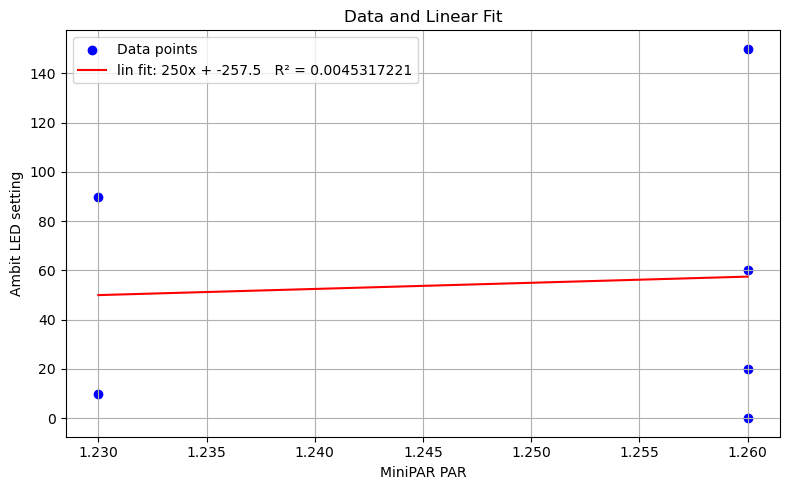

In [33]:
# Callibration of the light emmission of the Ambit LED
#ambit_reboot(PORT_AMBIT)
currents = [  10, 20, 60, 90, 150, 0]
reference_data = []
sensor_data = []
for I in currents:
    set_ambit_led(PORT_AMBIT, I)
    time.sleep(0.2)
    sens_val = get_par_MP(PORT_MINIPAR_EMIT)
    reference_data.append(I)
    sensor_data.append(sens_val)
   
# inspection plot for LED callibration
y = reference_data
x = sensor_data
coeffs = np.polyfit(x, y, 1)
y_pred = np.polyval(coeffs, x)
r2 = r_squared(y, y_pred)

plot_data_and_fit(x,y, coeffs, r2, ylabel="Ambit LED setting", xlabel="MiniPAR PAR")

In [34]:
# Upload LED gain calibration to the Ambit
light_gain = coeffs[0]
info = ambit_reboot(PORT_AMBIT)
old_slope = info.act_led_coeff
set_ambit_led_gain(PORT_AMBIT, light_gain)
info = ambit_reboot(PORT_AMBIT)
print(f"Old LED gain: {old_slope:.4f}, New LED gain: {info.act_led_coeff:.4f}")

Old LED gain: 250.0000, New LED gain: 250.0000


In [35]:
print(info)

FW: b'0.0.4' (MAC=38514fa89110, size=539216B, date=Jul)
Name: b'AmbitV004', valid: True
Calibration: Spec(light_slope)=0.032, Actinic(act_led_coeff)=250.0, Emit=1.0, Sun=1.0, Temp_offset=0.0, Temp_slope=1.0
Actinic curve: {50: 983, 100: 2032, 150: 3121, 200: 4174, 250: 5233}
ADPD cal: [0, 0, 0, 0, 0, 0] (chip v2)
MLX cal: [5829844, 78530480, 0, 6400, 4908155, 5829844, 67377408, -53767196, -39611924, 16384, 0, 10752, 10752, 69140899]
Metadata: {'lon': 0.0, 'lat': 0.0, 'alt': 0.0, 'time': 0, 'acc': 0.0, 'vacc': 0.0, 'info1': '8C', 'x': 0.0, 'y': 0.0, 'z': 0.0}


In [36]:
# optional check of the sensor health
# PAR sensor cross-check

set_current(port=PORT_DC_SOURCE, current=1.2)
time.sleep(1.0)
s1 = get_par_MP(PORT_MINIPAR_PAR)
s2 = get_par_MP(PORT_MINIPAR_EMIT)

print(f"PAR reading from PAR sensor: {s1:.4f}")
print(f"PAR reading from LED sensor: {s2:.4f}")
set_current(port=PORT_DC_SOURCE, current=0.0)

PAR reading from PAR sensor: 2.2700
PAR reading from LED sensor: 1.2600


In [ ]:
# # Continuous monitoring of the PAR sensor (press Ctrl+C to stop)
# set_current(port=PORT_DC_SOURCE, current=1.0)
# time.sleep(1.0)
# try:
#     while True:
#         s1 = get_par_MP(PORT_MINIPAR_PAR)
#         print(f"PAR reading from PAR sensor: {s1:.4f}")
#         time.sleep(1.0)
# except KeyboardInterrupt:
#     pass

# set_current(port=PORT_DC_SOURCE, current=0.0)

PAR reading from PAR sensor: 2.2800
PAR reading from PAR sensor: 2.2700


In [ ]:
# === Commit 2 verification ===
# Run this AFTER the discovery cells above so PORT_MINIPAR_PAR and PORT_AMBIT are set.
import importlib, helpers
importlib.reload(helpers)
from helpers import (
    findDevice, set_voltage, set_current, get_par_MP, get_par_AMB,
    set_par_gain, set_ambit_led_gain, set_ambit_led, ambit_reboot, AmbitInfo,
    AmbitProto, MiniParProto, DCSourceProto,
)

assert "Calibratron\\helpers.py" in helpers.__file__, \
    f"Wrong helpers resolved: {helpers.__file__}"
print("helpers from:", helpers.__file__)

# 1. PAR readouts (regression check)
print(f"MP raw : {get_par_MP(PORT_MINIPAR_PAR, raw=True):.3f}")
print(f"AMB raw: {get_par_AMB(PORT_AMBIT, raw=True):.3f}")

# 2. set_par_gain roundtrip - read original, set test value, verify, restore
TEST_VALUE = 0.1892
info = ambit_reboot(PORT_AMBIT)
original = info.light_slope
print(f"\nOriginal light_slope: {original:.4f}")

set_par_gain(PORT_AMBIT, TEST_VALUE)
info = ambit_reboot(PORT_AMBIT)
print(f"After set_par_gain({TEST_VALUE}): {info.light_slope:.4f}")
assert abs(info.light_slope - TEST_VALUE) < 1e-4, \
    f"set_par_gain regressed: expected ~{TEST_VALUE}, got {info.light_slope}"

set_par_gain(PORT_AMBIT, original)
info = ambit_reboot(PORT_AMBIT)
print(f"Restored: {info.light_slope:.4f}")
assert abs(info.light_slope - original) < 1e-4, "restore failed"

# 3. AmbitInfo populated end-to-end
assert info.MAC and info.fw_size > 0 and info.adpd_chip_version is not None, \
    "AmbitInfo fields missing - parser regression"
print(f"AmbitInfo: name={info.name!r} FW={info.FW!r} MAC={info.MAC} "
      f"actinic_curve={info.actinic_curve} adpd_chip_v={info.adpd_chip_version}")

print("\n=== Commit 2: PASS ===")

In [ ]:
# === Commit 3 verification (AmbitInfo -> @dataclass) ===
# Run AFTER discovery so PORT_AMBIT is set.
import importlib, helpers, dataclasses
importlib.reload(helpers)

# 1. Sanity: AmbitInfo is now a dataclass with expected defaults
info = helpers.AmbitInfo()
assert dataclasses.is_dataclass(info), "AmbitInfo should be a @dataclass"
assert info.FW == b"" and info.IsValid is False and info.name == b""
assert info.MAC == "" and info.fw_size == 0 and info.fw_date == ""
assert info.adpd_chip_version is None
assert info.metadata == {} and info.actinic_curve == {}
assert info.adpd_calibration == [] and info.mlx_calibration == []
assert info.act_led_coeff == 0.0 and info.light_slope == 0.0
print("Defaults OK")

# 2. Each AmbitInfo() must have its own dict/list (no shared mutable defaults)
a, b = helpers.AmbitInfo(), helpers.AmbitInfo()
a.metadata["x"] = 1; a.actinic_curve[50] = 1; a.adpd_calibration.append(1)
assert b.metadata == {} and b.actinic_curve == {} and b.adpd_calibration == [], \
    "Mutable defaults are shared between instances - default_factory missing"
print("Mutable defaults isolated per-instance OK")

# 3. processInfo still parses a real reboot dump end-to-end
info = helpers.ambit_reboot(PORT_AMBIT)
assert info.MAC and info.fw_size > 0 and info.adpd_chip_version is not None
assert info.light_slope > 0 and info.act_led_coeff > 0
assert info.actinic_curve and len(info.adpd_calibration) == 6
assert len(info.mlx_calibration) >= 14 and info.metadata
print("processInfo parser OK")

# 4. Custom __str__ preserved (not the auto-generated dataclass repr)
out = str(info)
assert "Calibration:" in out and "Actinic curve:" in out and "MLX cal:" in out, \
    "Custom __str__ was clobbered by dataclass __repr__"
print(out)

print("\n=== Commit 3: PASS ===")